In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [22]:
df = pd.read_csv(r"..\Dataset\dataset_module_zero_DM2.csv")
df.shape

(8460, 60)

In [3]:
nf_df = df.select_dtypes(include=[np.number])
print(type(nf_df))

<class 'pandas.DataFrame'>


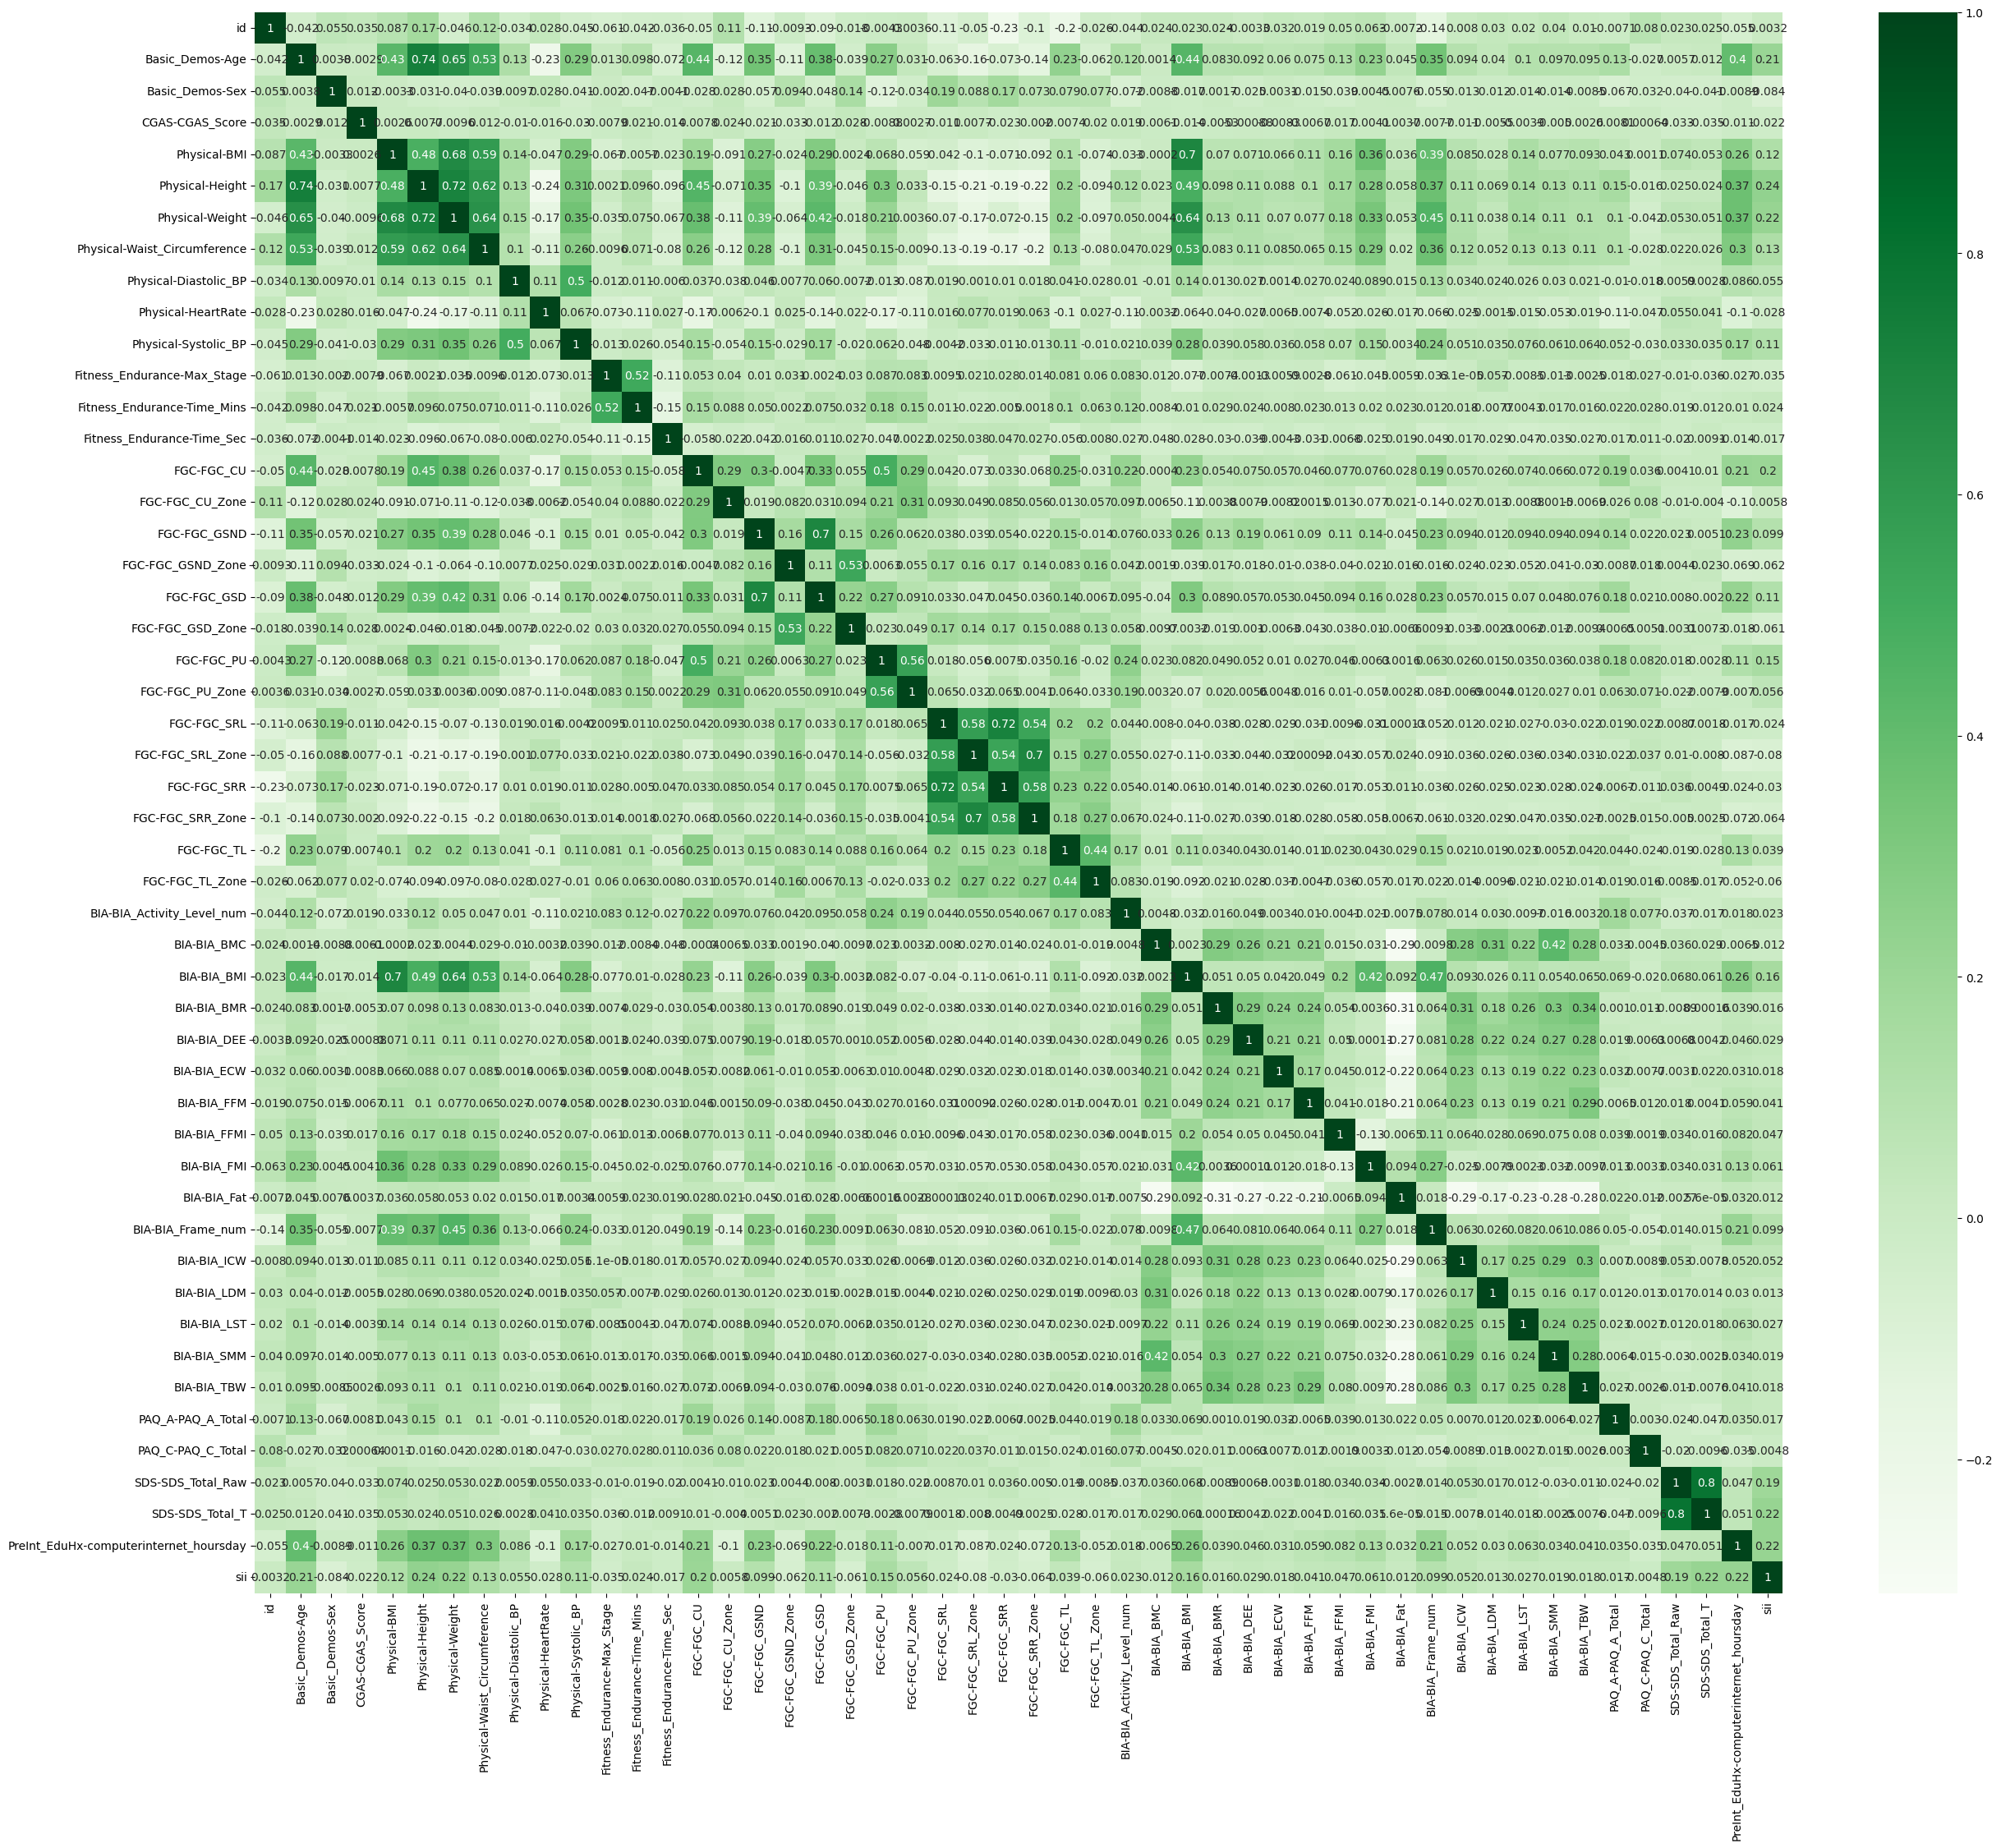

In [4]:
plt.figure(figsize=(30, 25))
sns.heatmap(nf_df.corr(), cmap="Greens", annot=True)
plt.show()

In [5]:
df["SDS-SDS_Total_T"].describe()

count    8460.000000
mean       57.161250
std         9.658925
min        38.000000
25%        54.274656
50%        55.513729
75%        58.000000
max       100.000000
Name: SDS-SDS_Total_T, dtype: float64

In [6]:
df["SDS-SDS_Total_Raw"].describe()

count    8460.000000
mean       40.807800
std         7.288258
min        17.000000
25%        38.500000
50%        39.890893
75%        41.500000
max        96.000000
Name: SDS-SDS_Total_Raw, dtype: float64

In [7]:
# Si rimuove SDS-SDS_Total_Raw perché ha correlazione 0.8 con SDS-SDS_Total_T ma è più grezzo
df.drop(["SDS-SDS_Total_Raw"], inplace=True, axis=1)

In [8]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

### PCA on the Physical Columns : Physical-BMI, Physical-Height, Physical-Weight, Physical-Waist_Circumference

In [9]:
physical_cols = ['Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference']
physical_df = df[physical_cols]

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize the data (Mean=0, Variance=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(physical_df)

In [11]:
# 2. Initialize and fit PCA
pca = PCA(n_components=2) # Reducing from 4 columns to 2
pca_data = pca.fit_transform(scaled_data)

# 3. Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=pca_data, columns=['Body_Mass_Index_Global', 'Body_Proportion'])
pca_df

,Body_Mass_Index_Global,Body_Proportion
0,-1.624057,0.612212
1,-2.432146,0.025562
2,-0.562707,-0.395585
3,-0.367187,-0.074401
4,-0.204319,-0.478938
...,...,...
8455,-2.265716,0.546502
8456,-0.541221,-0.242228
8457,1.939509,4.236281
8458,1.574109,-0.206674


In [12]:
pca.explained_variance_ratio_

array([0.71698266, 0.12992701])

In [13]:
pca.components_

array([[ 0.47712248,  0.49207886,  0.53225806,  0.49690431],
       [ 0.75741864, -0.64981405, -0.02258489, -0.05957025]])

In [14]:
# Remove them four columns from the dataframe
df.drop(physical_cols, inplace=True, axis=1)
df.shape

(8460, 55)

In [15]:
# Add the two columns created using PCA above
df = pd.concat([df, pca_df], axis=1)
df.shape

(8460, 57)

### PCA on the Fitness Gram Columns:
Questa PCA non va bene per via delle colonne binarie imputed 

In [16]:
sar_cols = ['FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone']
sar_df = df[sar_cols]

In [ ]:
# 1. Standardize the data (Mean=0, Variance=1)
scaled_sar_data = scaler.fit_transform(sar_df)

# 2. Initialize and fit PCA
pca_sar = PCA(n_components=2) # Reducing from 4 columns to 2
pca_sar_data = pca_sar.fit_transform(scaled_sar_data)

# 3. Create a new DataFrame with the principal components
pca_sar_df = pd.DataFrame(data=pca_sar_data, columns=['SR_Global', 'SR_Zone_Divergence'])
pca_sar_df

,SR_Global,Zone_vs_Raw_Discrepancy
0,-2.428862,-0.963833
1,1.690254,-0.376545
2,1.292504,0.017609
3,-2.235661,-1.155859
4,0.905538,0.323697
...,...,...
8455,-1.038431,0.027722
8456,-3.019813,-0.377654
8457,1.121996,0.189433
8458,1.497052,-0.184518


In [18]:
pca_sar.explained_variance_ratio_

array([0.70758068, 0.14805123])

In [19]:
pca_sar.components_

array([[ 0.50241644,  0.49789139,  0.50207272,  0.49759911],
       [-0.49646917,  0.50116561, -0.49901873,  0.50332067]])

In [20]:
# Remove them four columns from the dataframe
df.drop(sar_cols, inplace=True, axis=1)
df.shape

(8460, 53)

In [21]:
# Add the two columns created using PCA above
df = pd.concat([df, pca_sar_df], axis=1)
df.shape

(8460, 55)